Математическое ожидание: 0.501681640625
Дисперсия: 0.08348360749816897
Второй момент: 0.3351680760383606
Третий момент: 0.25178065845475067


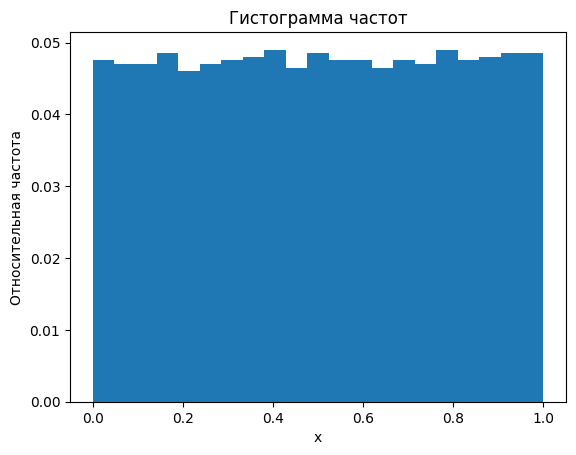

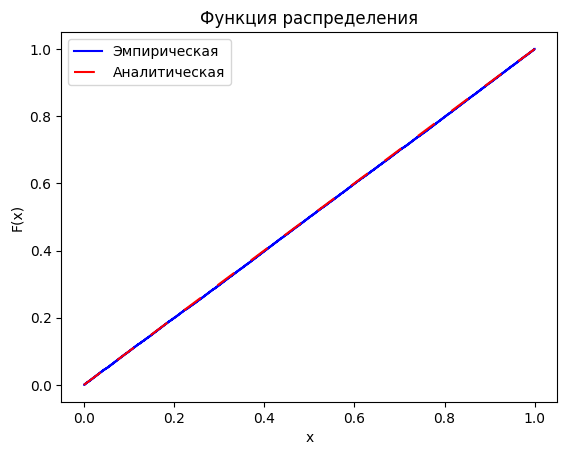

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from pyerf import erfinv

Y0 = 3091
M = 4096
a = 5
N = 2000
K = 21

Y = Y0
X = []


def func(x):
    return x


for _ in range(N):
    Y = (a * Y) % M
    X.append(Y / M)

hist = [0] * K
h = 1.0 / K

for x in X:
    index = int(x / h)
    if index == K:
        index = K - 1
    hist[index] += 1

hist_norm = [v / N for v in hist]

X_sorted = sorted(X)
F = []

for i in range(N):
    F.append((i + 1) / N)

mean = sum(X) / N
second_moment = sum(x**2 for x in X) / N
third_moment = sum(x**3 for x in X) / N
variance = second_moment - mean**2

print("Математическое ожидание:", mean)
print("Дисперсия:", variance)
print("Второй момент:", second_moment)
print("Третий момент:", third_moment)

x_hist = [i * h for i in range(K)]

plt.figure()
plt.bar(x_hist, hist_norm, width=h, align="edge")
plt.title("Гистограмма частот")
plt.xlabel("x")
plt.ylabel("Относительная частота")
plt.show()

plt.figure()
plt.step(X_sorted, F, where="post", color="blue", label="Эмпирическая")

x_theor = np.linspace(0, 1, N)
y_theor = [func(x) for x in x_theor]
plt.plot(
    x_theor,
    y_theor,
    color="red",
    linestyle="--",
    dashes=(10, 10),
    label="Аналитическая",
)

plt.title("Функция распределения")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.legend()
plt.show()

In [2]:
n0 = N / K

chi2 = 0.0
for ni in hist:
    chi2 += (ni - n0) ** 2 / n0

print("χ² =", chi2)


def kolmogorov(lambda_val, terms=10):
    s = 0
    for k in range(1, terms + 1):
        s += (-1) ** (k - 1) * math.exp(-2 * (k**2) * (lambda_val**2))
    return max(0, min(1, 2 * s))


D = 0

for i in range(N):
    dp = abs((i + 1) / N - func(X_sorted[i]))
    dm = abs(func(X_sorted[i]) - i / N)
    D = max(D, dp, dm)

lmb = D * N**0.5

print("D =", D)
print("λ =", lmb)
print("P(λ) =", kolmogorov(lmb))

χ² = 0.586
D = 0.004115234375000054
λ = 0.18403887611687966
P(λ) = 0.9995465395193683


In [3]:
p = 0.65
q = 1 - p
alpha = 0.05

Y = [1 if x >= p else 0 for x in X]

K = 0
for i in range(1, N):
    if Y[i - 1] == 0 and Y[i] == 1:
        K += 1
if Y[N - 1] == 1:
    K += 1

N1 = sum(Y)
M_obs = N1 / K

M = p / q
D = p / q**2


def quantile(alpha):
    p = (2 - alpha) / 2
    return math.sqrt(2) * erfinv(2 * p - 1)


t = quantile(alpha)

RH = M - t * (D / K) ** 0.5
RB = M + t * (D / K) ** 0.5

print(f"Средняя длина серии единиц (набл.): {M_obs:.3f}")
print(f"Теоретическая длина серии: {M:.3f}")
print(f"Критический интервал: [{RH:.3f}, {RB:.3f}]")

if RH <= M_obs <= RB:
    print("Гипотеза о независимости чисел НЕ ОТВЕРГАЕТСЯ")
else:
    print("Гипотеза о независимости чисел ОТВЕРГАЕТСЯ")

Средняя длина серии единиц (набл.): 1.675
Теоретическая длина серии: 1.857
Критический интервал: [1.637, 2.077]
Гипотеза о независимости чисел НЕ ОТВЕРГАЕТСЯ
